In [1]:
import os
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

print("\nDataset structure:")
for root, directories, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    if level <= 3:
        print("  " * level + os.path.basename(root) + "/")

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

Dataset structure:
input/
  datasets/
    puneet6060/
      intel-image-classification/


In [2]:
from pathlib import Path

DATA_ROOT = Path("/kaggle/input/datasets/puneet6060/intel-image-classification")

print("Image directories found:\n")

for folder_name in ["seg_train", "seg_test", "seg_pred"]:
    matches = list(DATA_ROOT.rglob(folder_name))

    if matches:
        for match in matches:
            print(f"{folder_name}: {match}")
    else:
        print(f"{folder_name}: NOT FOUND")

Image directories found:

seg_train: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_train
seg_train: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train
seg_test: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test
seg_test: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test
seg_pred: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_pred
seg_pred: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_pred/seg_pred


In [3]:
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Configuration
IMG_SIZE = (150, 150)
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

TRAIN_DIR = Path(
    "/kaggle/input/datasets/puneet6060/"
    "intel-image-classification/seg_train/seg_train"
)

TEST_DIR = Path(
    "/kaggle/input/datasets/puneet6060/"
    "intel-image-classification/seg_test/seg_test"
)

PREDICT_DIR = Path(
    "/kaggle/input/datasets/puneet6060/"
    "intel-image-classification/seg_pred/seg_pred"
)

OUTPUT_DIR = Path("/kaggle/working/assignment-1-artifacts")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Use both T4 GPUs
strategy = tf.distribute.MirroredStrategy()

print("TensorFlow version:", tf.__version__)
print("Number of synchronized GPUs:", strategy.num_replicas_in_sync)
print("Training directory exists:", TRAIN_DIR.exists())
print("Test directory exists:", TEST_DIR.exists())
print("Prediction directory exists:", PREDICT_DIR.exists())

# Audit image counts and file types
valid_extensions = {".jpg", ".jpeg", ".png"}

def audit_directory(directory):
    records = []

    for class_directory in sorted(
        path for path in directory.iterdir() if path.is_dir()
    ):
        image_files = [
            path for path in class_directory.iterdir()
            if path.suffix.lower() in valid_extensions
        ]

        records.append({
            "class": class_directory.name,
            "image_count": len(image_files)
        })

    return pd.DataFrame(records)

train_audit = audit_directory(TRAIN_DIR)
test_audit = audit_directory(TEST_DIR)

print("\nTraining-set audit:")
display(train_audit)

print("\nTest-set audit:")
display(test_audit)

print("\nTotal training images:", train_audit["image_count"].sum())
print("Total test images:", test_audit["image_count"].sum())
print("Classes:", train_audit["class"].tolist())

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
TensorFlow version: 2.20.0
Number of synchronized GPUs: 2
Training directory exists: True
Test directory exists: True
Prediction directory exists: True

Training-set audit:


I0000 00:00:1788240295.502283      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788240295.505540      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


,class,image_count
0,buildings,2191
1,forest,2271
2,glacier,2404
3,mountain,2512
4,sea,2274
5,street,2382



Test-set audit:


,class,image_count
0,buildings,437
1,forest,474
2,glacier,553
3,mountain,525
4,sea,510
5,street,501



Total training images: 14034
Total test images: 3000
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


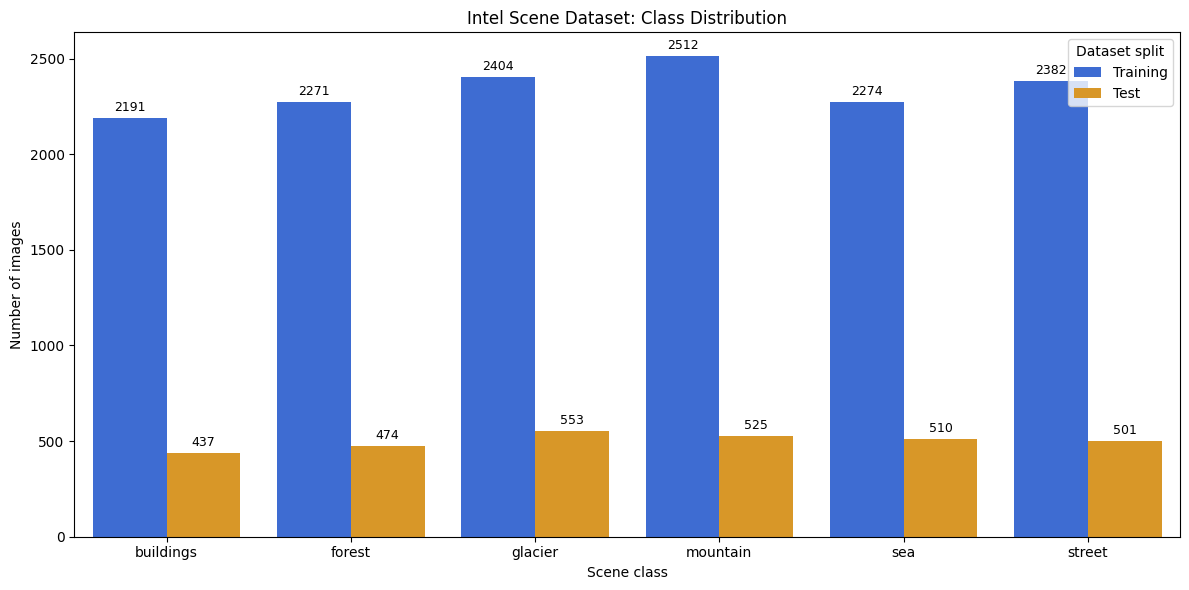

In [4]:
# Class-distribution visualization
distribution = train_audit.merge(
    test_audit,
    on="class",
    suffixes=("_train", "_test")
)

distribution_long = distribution.melt(
    id_vars="class",
    value_vars=["image_count_train", "image_count_test"],
    var_name="split",
    value_name="image_count"
)

distribution_long["split"] = distribution_long["split"].map({
    "image_count_train": "Training",
    "image_count_test": "Test"
})

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=distribution_long,
    x="class",
    y="image_count",
    hue="split",
    palette=["#2563EB", "#F59E0B"]
)

plt.title("Intel Scene Dataset: Class Distribution")
plt.xlabel("Scene class")
plt.ylabel("Number of images")
plt.legend(title="Dataset split")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, fontsize=9)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "class-distribution.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

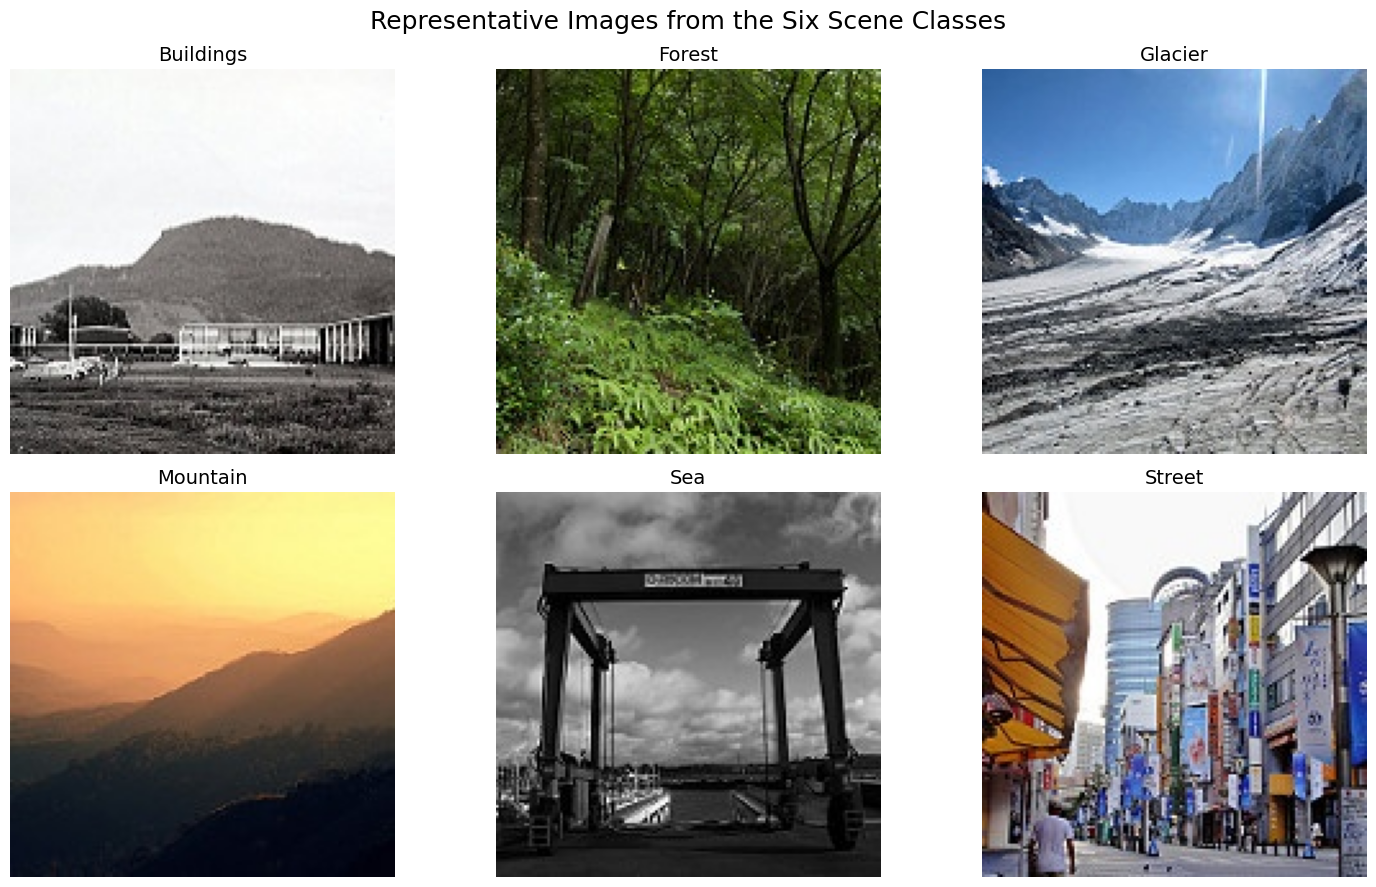

In [5]:
# Display one representative image from every class
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for axis, class_name in zip(axes, train_audit["class"]):
    class_directory = TRAIN_DIR / class_name

    image_path = sorted([
        path for path in class_directory.iterdir()
        if path.suffix.lower() in valid_extensions
    ])[0]

    image = tf.keras.utils.load_img(image_path)
    axis.imshow(image)
    axis.set_title(class_name.title(), fontsize=14)
    axis.axis("off")

plt.suptitle(
    "Representative Images from the Six Scene Classes",
    fontsize=18
)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "sample-images.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

In [6]:
# Create stratified-by-folder training and validation datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# Keep the test dataset untouched and ordered for final evaluation
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    shuffle=False,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names
number_of_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", number_of_classes)
print("Training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print(
    "Validation batches:",
    tf.data.experimental.cardinality(validation_ds).numpy()
)
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

# Pipeline performance optimization
train_ds = train_ds.prefetch(AUTOTUNE)
validation_ds = validation_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6
Training batches: 176
Validation batches: 44
Test batches: 47


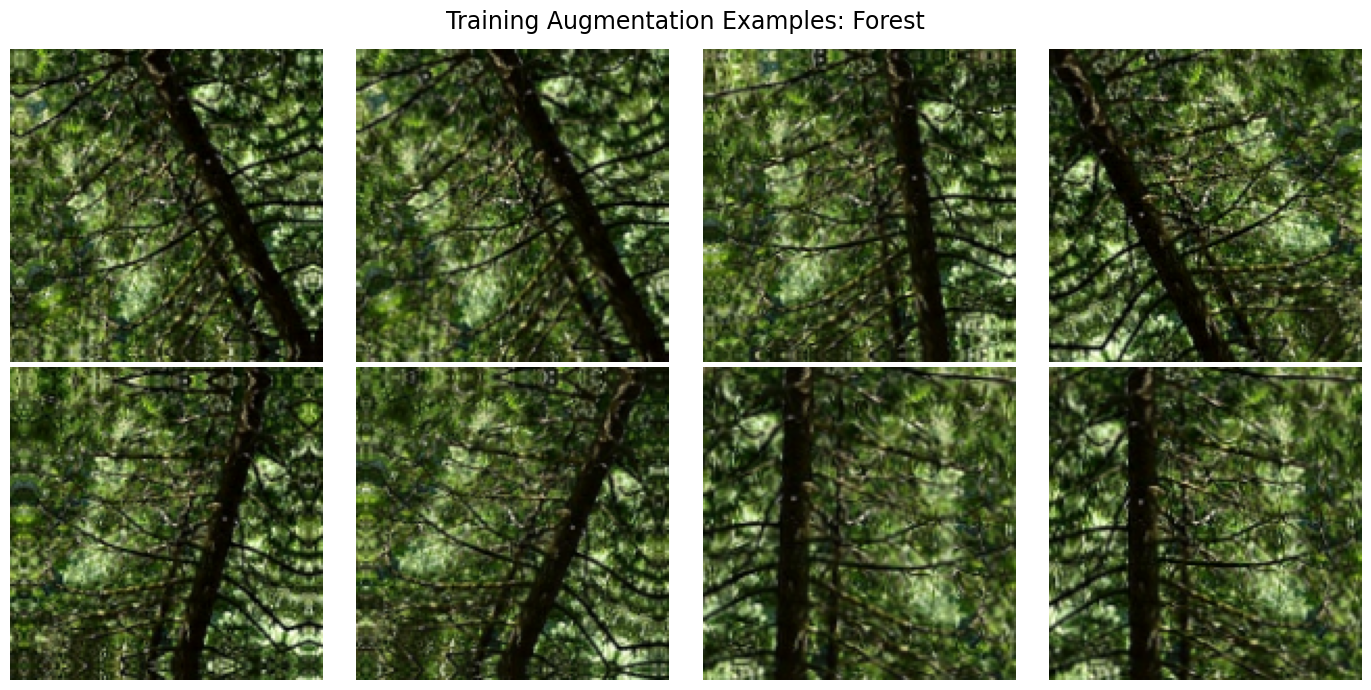

In [7]:
# Training-only image augmentation
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.08),
        tf.keras.layers.RandomZoom(0.10),
        tf.keras.layers.RandomContrast(0.10)
    ],
    name="data_augmentation"
)

# Verify augmentation visually
for images, labels in train_ds.take(1):
    sample_image = images[0]
    sample_label = class_names[np.argmax(labels[0])]

    fig, axes = plt.subplots(2, 4, figsize=(14, 7))

    for axis in axes.flatten():
        augmented_image = data_augmentation(
            tf.expand_dims(sample_image, axis=0),
            training=True
        )[0]

        axis.imshow(
            tf.cast(
                tf.clip_by_value(augmented_image, 0, 255),
                tf.uint8
            )
        )
        axis.axis("off")

    plt.suptitle(
        f"Training Augmentation Examples: {sample_label.title()}",
        fontsize=17
    )
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / "augmentation-examples.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()

In [8]:
from tensorflow.keras import layers, models, callbacks

tf.keras.backend.clear_session()

with strategy.scope():
    custom_cnn = models.Sequential(
        [
            layers.Input(shape=(*IMG_SIZE, 3)),
            data_augmentation,
            layers.Rescaling(1.0 / 255),

            layers.Conv2D(32, 3, padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(),

            layers.Conv2D(64, 3, padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(),

            layers.Conv2D(128, 3, padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(),

            layers.Conv2D(256, 3, padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(),

            layers.GlobalAveragePooling2D(),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.40),
            layers.Dense(number_of_classes, activation="softmax")
        ],
        name="custom_scene_cnn"
    )

    custom_cnn.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

custom_cnn.summary()

Model: "custom_scene_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,006 (1.62 MB)

 Trainable params: 423,046 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [9]:
custom_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.30,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        OUTPUT_DIR / "best-custom-cnn.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

custom_history = custom_cnn.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=15,
    callbacks=custom_callbacks,
    verbose=1
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

In [10]:
custom_history_df = pd.DataFrame(custom_history.history)

custom_summary = {
    "epochs_completed": len(custom_history_df),
    "best_training_accuracy": custom_history_df["accuracy"].max(),
    "best_validation_accuracy": custom_history_df["val_accuracy"].max(),
    "lowest_validation_loss": custom_history_df["val_loss"].min()
}

display(pd.DataFrame([custom_summary]).round(4))

,epochs_completed,best_training_accuracy,best_validation_accuracy,lowest_validation_loss
0,13,0.8837,0.8029,0.5437


In [11]:
tf.keras.backend.clear_session()

with strategy.scope():
    mobile_base = tf.keras.applications.MobileNetV2(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze pretrained convolutional features initially
    mobile_base.trainable = False

    inputs = layers.Input(shape=(*IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    x = mobile_base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(
        number_of_classes,
        activation="softmax"
    )(x)

    transfer_model = tf.keras.Model(
        inputs,
        outputs,
        name="mobilenetv2_scene_classifier"
    )

    transfer_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

transfer_model.summary()

print("Total parameters:", transfer_model.count_params())
print(
    "Trainable parameters:",
    sum(
        tf.keras.backend.count_params(weight)
        for weight in transfer_model.trainable_weights
    )
)

/tmp/ipykernel_23/2410114480.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobile_base = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_scene_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Total parameters: 2265670
Trainable parameters: 7686


In [12]:
transfer_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.30,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        OUTPUT_DIR / "best-transfer-model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

transfer_history = transfer_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10,
    callbacks=transfer_callbacks,
    verbose=1
)

Epoch 1/10
INFO:tensorflow:Collective all_reduce tensors: 2 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6208 - loss: 1.0733
Epoch 1: val_accuracy improved from None to 0.87598, saving model to /kaggle/working/assignment-1-artifacts/best-transfer-model.keras

Epoch 1: finished saving model to /kaggle/working/assignment-1-artifacts/best-transfer-model.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 18s 70ms/step - accuracy: 0.7477 - loss: 0.7023 - val_accuracy: 0.8760 - val_loss: 0.3529 - learning_rate: 0.0010
Epoch 2/10
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8364 - loss: 0.4660
Epoch 2: val_accuracy improved from 0.87598 to 0.88275, saving model to /kaggle/working/assignment-1-artifacts/best-transfer-model.keras

Epoch 2: finished saving model to /kaggle/working/assignment-1-artifacts/best-transfer-model.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy

In [13]:
# Fine-tune only the final portion of MobileNetV2
mobile_base.trainable = True

for layer in mobile_base.layers[:-30]:
    layer.trainable = False

# Keep Batch Normalization layers frozen
for layer in mobile_base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

with strategy.scope():
    transfer_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

print(
    "Trainable parameters after unfreezing:",
    sum(
        tf.keras.backend.count_params(weight)
        for weight in transfer_model.trainable_weights
    )
)

fine_tune_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.30,
        patience=1,
        min_lr=1e-7,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        OUTPUT_DIR / "best-fine-tuned-model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

fine_tune_history = transfer_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=6,
    callbacks=fine_tune_callbacks,
    verbose=1
)

Trainable parameters after unfreezing: 1518406
Epoch 1/6
INFO:tensorflow:Collective all_reduce tensors: 12 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8754 - loss: 0.3344
Epoch 1: val_accuracy improved from None to 0.89950, saving model to /kaggle/working/assignment-1-artifacts/best-fine-tuned-model.keras

Epoch 1: finished saving model to /kaggle/working/assignment-1-artifacts/best-fine-tuned-model.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.8847 - loss: 0.3142 - val_accuracy: 0.8995 - val_loss: 0.2683 - learning_rate: 1.0000e-05
Epoch 2/6
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8909 - loss: 0.3056
Epoch 2: val_accuracy improved from 0.89950 to 0.90128, saving model to /kaggle/working/assignment-1-artifacts/best-fine-tuned-model.keras

Epoch 2: finished saving model to /kaggle/working/assignment-1-artifacts/best-fine-tuned-model.

In [14]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

# Load the best saved custom CNN
with strategy.scope():
    best_custom_model = tf.keras.models.load_model(
        OUTPUT_DIR / "best-custom-cnn.keras"
    )

custom_test_loss, custom_test_accuracy = best_custom_model.evaluate(
    test_ds,
    verbose=1
)

fine_tuned_test_loss, fine_tuned_test_accuracy = transfer_model.evaluate(
    test_ds,
    verbose=1
)

# Ordered ground-truth labels because test_ds uses shuffle=False
y_true = np.concatenate([
    np.argmax(labels.numpy(), axis=1)
    for images, labels in test_ds
])

# Final fine-tuned model predictions
fine_tuned_probabilities = transfer_model.predict(
    test_ds,
    verbose=1
)
y_pred = np.argmax(fine_tuned_probabilities, axis=1)

precision, recall, macro_f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

comparison_results = pd.DataFrame([
    {
        "model": "Custom CNN",
        "test_loss": custom_test_loss,
        "test_accuracy": custom_test_accuracy,
        "macro_precision": np.nan,
        "macro_recall": np.nan,
        "macro_f1": np.nan
    },
    {
        "model": "Fine-tuned MobileNetV2",
        "test_loss": fine_tuned_test_loss,
        "test_accuracy": fine_tuned_test_accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1
    }
])

display(comparison_results.round(4))

comparison_results.to_csv(
    OUTPUT_DIR / "model-comparison.csv",
    index=False
)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

classification_report_df = pd.DataFrame(report).transpose()

display(classification_report_df.round(4))

classification_report_df.to_csv(
    OUTPUT_DIR / "classification-report.csv"
)

47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.8010 - loss: 0.5698
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9027 - loss: 0.2487
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step


,model,test_loss,test_accuracy,macro_precision,macro_recall,macro_f1
0,Custom CNN,0.5698,0.8010,NaN,NaN,NaN
1,Fine-tuned MobileNetV2,0.2487,0.9027,0.9043,0.9063,0.9048


,precision,recall,f1-score,support
buildings,0.8849,0.9497,0.9161,437.0000
forest,0.9874,0.9916,0.9895,474.0000
glacier,0.8423,0.8210,0.8315,553.0000
mountain,0.8608,0.8248,0.8424,525.0000
sea,0.9072,0.9588,0.9323,510.0000
street,0.9430,0.8922,0.9169,501.0000
accuracy,0.9027,0.9027,0.9027,0.9027
macro avg,0.9043,0.9063,0.9048,3000.0000
weighted avg,0.9025,0.9027,0.9021,3000.0000


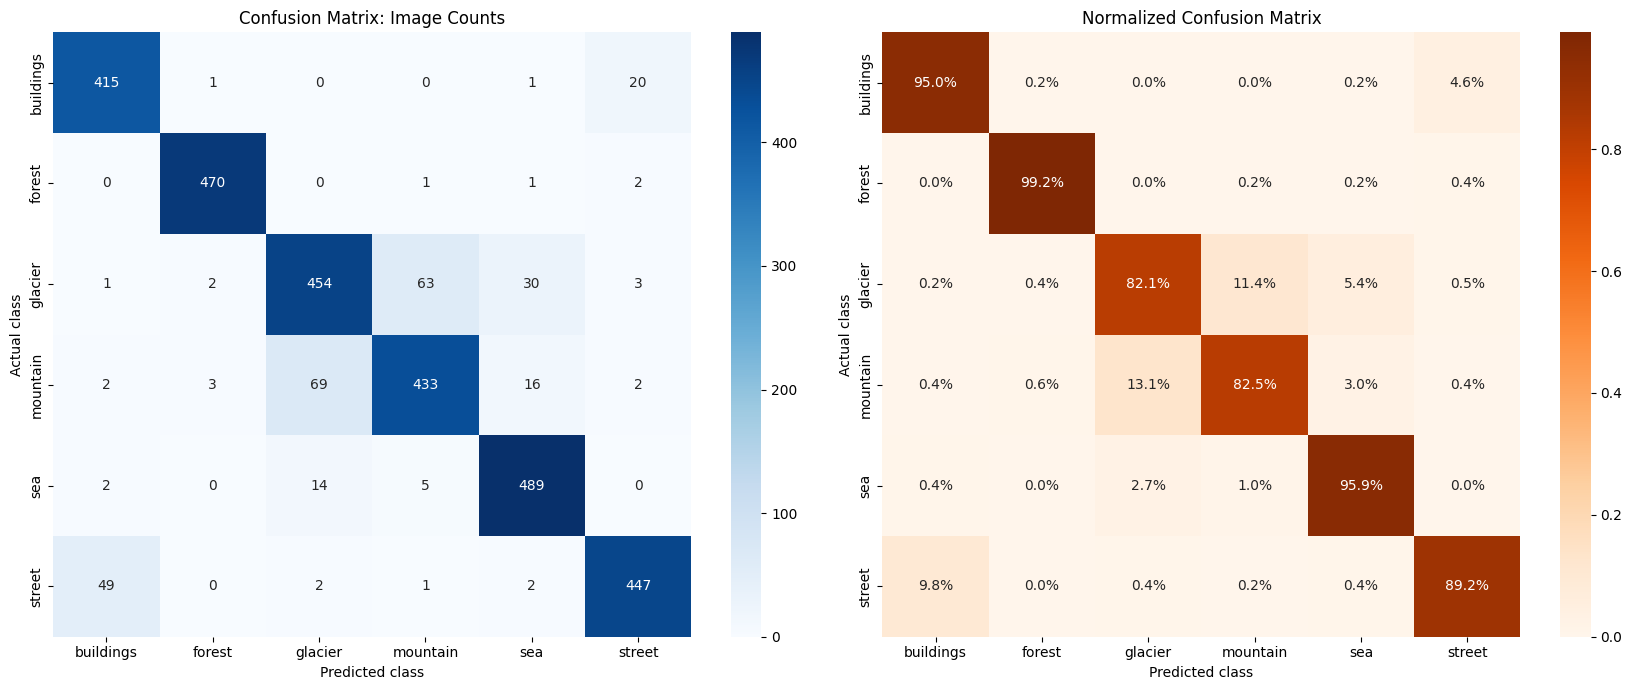

In [15]:
# Confusion matrix
confusion = confusion_matrix(y_true, y_pred)
normalized_confusion = confusion.astype(float) / confusion.sum(
    axis=1,
    keepdims=True
)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0]
)

axes[0].set_title("Confusion Matrix: Image Counts")
axes[0].set_xlabel("Predicted class")
axes[0].set_ylabel("Actual class")

sns.heatmap(
    normalized_confusion,
    annot=True,
    fmt=".1%",
    cmap="Oranges",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1]
)

axes[1].set_title("Normalized Confusion Matrix")
axes[1].set_xlabel("Predicted class")
axes[1].set_ylabel("Actual class")

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "confusion-matrices.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

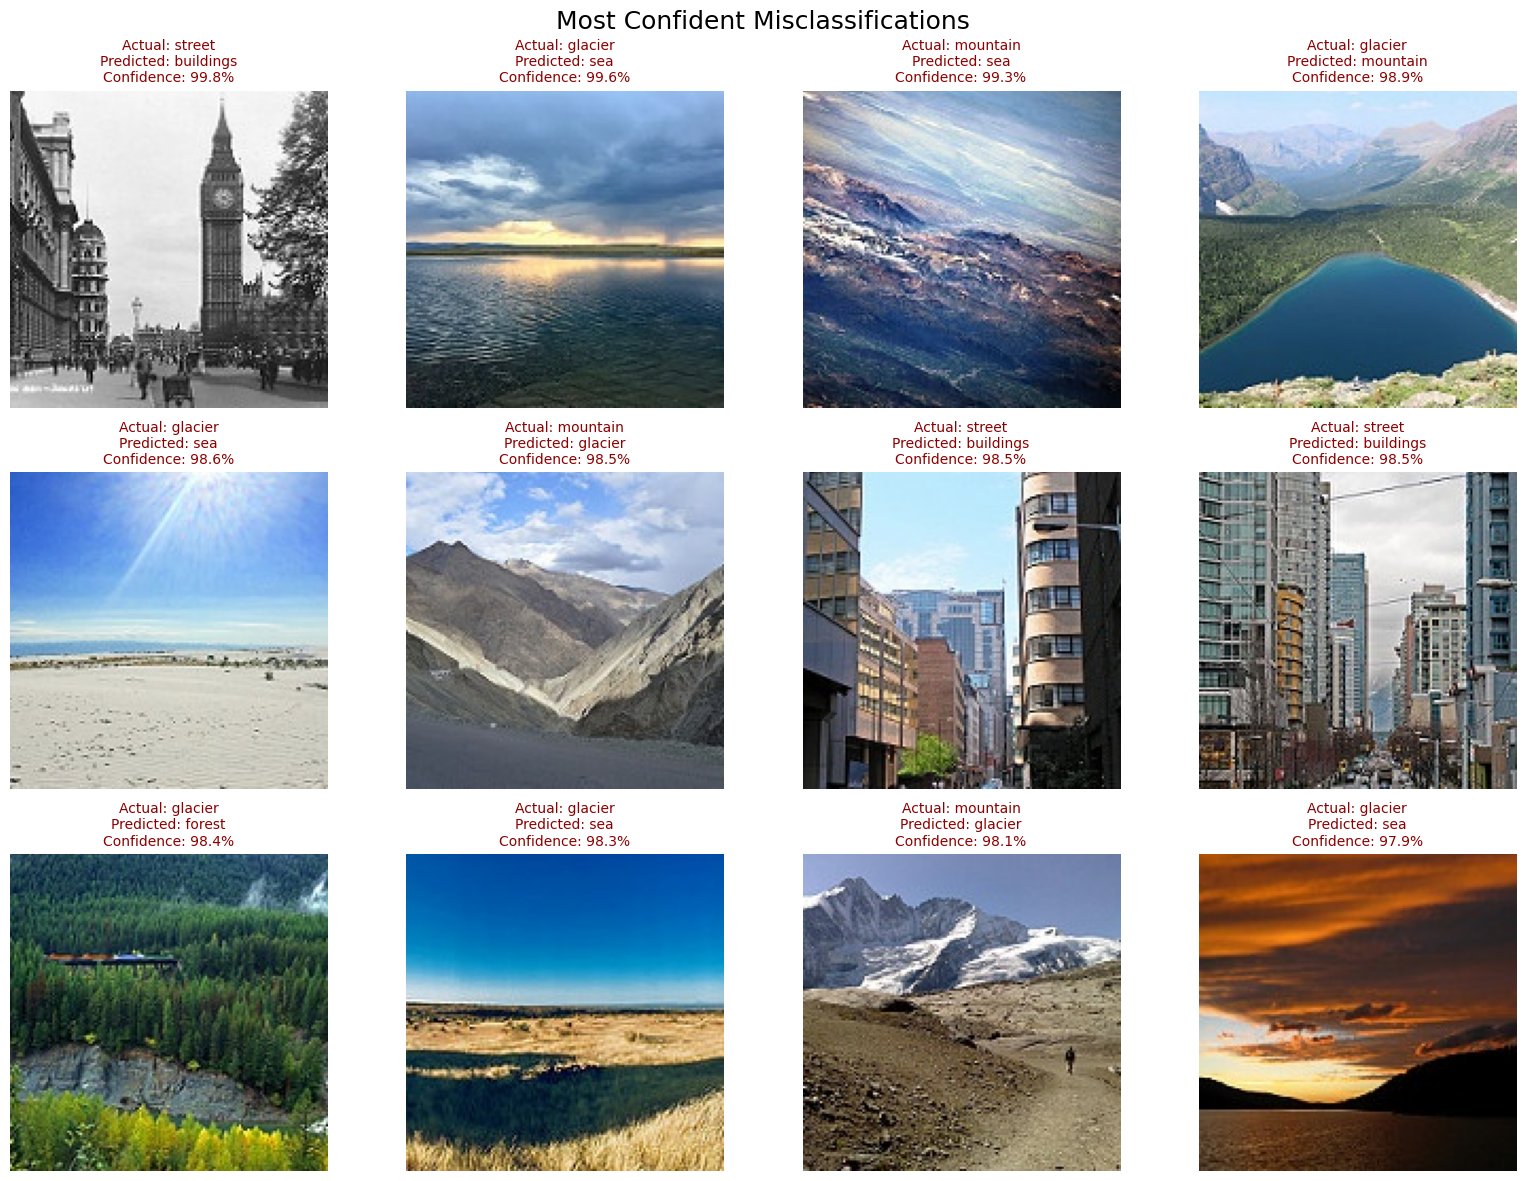

In [16]:
# Reconstruct ordered test paths used by shuffle=False
test_file_paths = sorted([
    path
    for class_directory in sorted(TEST_DIR.iterdir())
    if class_directory.is_dir()
    for path in class_directory.iterdir()
    if path.suffix.lower() in valid_extensions
])

assert len(test_file_paths) == len(y_true)

prediction_confidence = np.max(
    fine_tuned_probabilities,
    axis=1
)

incorrect_indices = np.where(y_pred != y_true)[0]

# Select the 12 most confident incorrect predictions
most_confident_errors = incorrect_indices[
    np.argsort(
        prediction_confidence[incorrect_indices]
    )[-12:]
][::-1]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for axis, index in zip(
    axes.flatten(),
    most_confident_errors
):
    image = tf.keras.utils.load_img(
        test_file_paths[index],
        target_size=IMG_SIZE
    )

    axis.imshow(image)
    axis.set_title(
        f"Actual: {class_names[y_true[index]]}\n"
        f"Predicted: {class_names[y_pred[index]]}\n"
        f"Confidence: {prediction_confidence[index]:.1%}",
        color="darkred",
        fontsize=10
    )
    axis.axis("off")

plt.suptitle(
    "Most Confident Misclassifications",
    fontsize=18
)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "misclassified-images.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

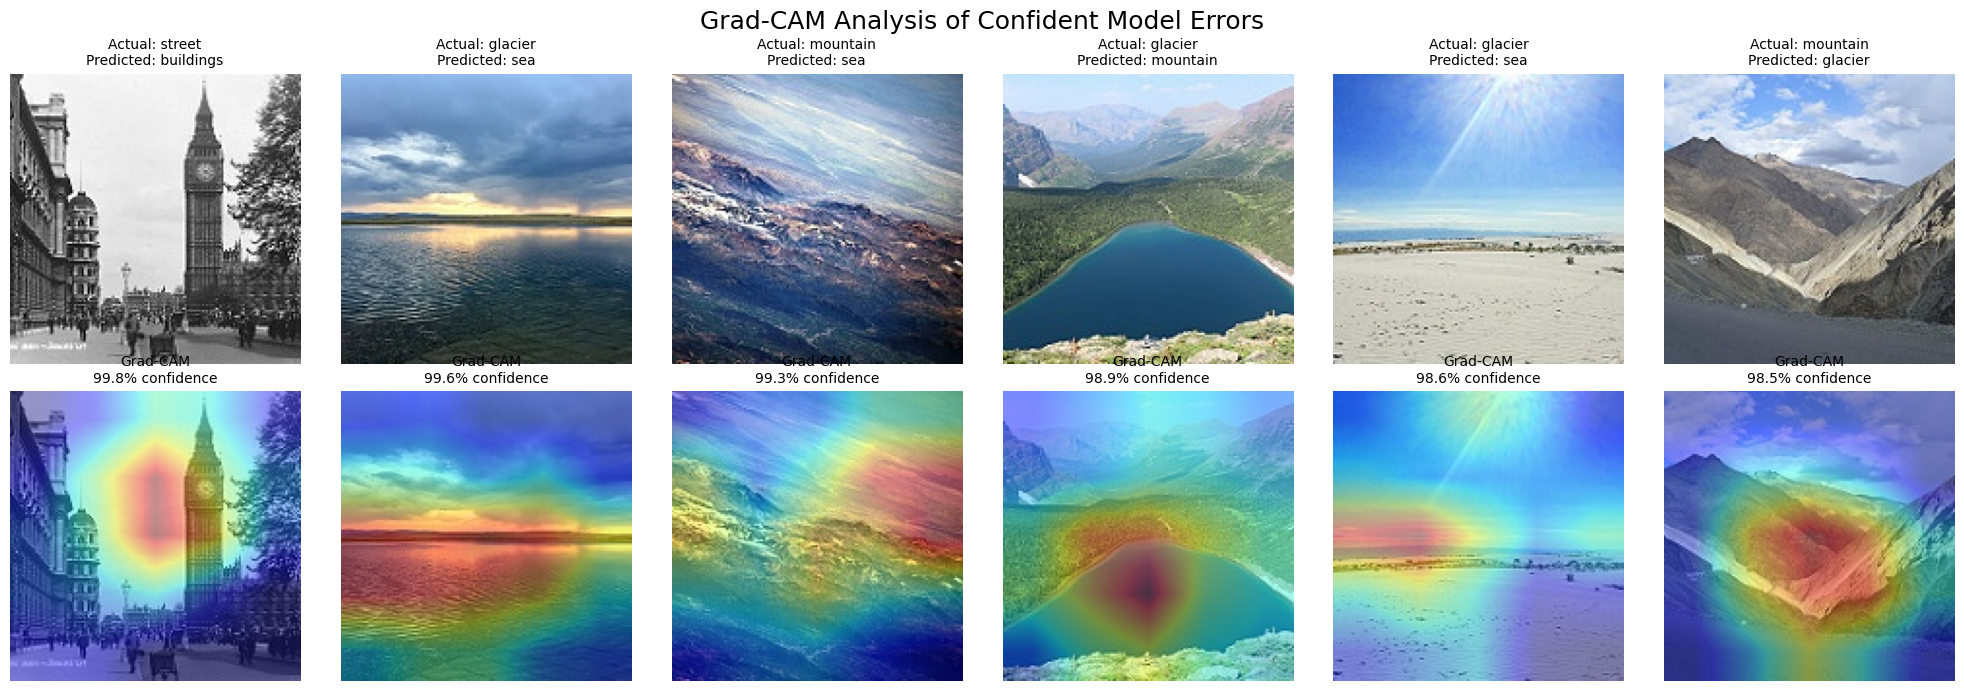

In [17]:
# Grad-CAM explainability for the nested MobileNetV2 model
last_conv_layer = mobile_base.get_layer("out_relu")

feature_extractor = tf.keras.Model(
    inputs=mobile_base.input,
    outputs=last_conv_layer.output
)

pooling_layer = transfer_model.get_layer(
    "global_average_pooling2d"
)
dropout_layer = transfer_model.get_layer("dropout")
classifier_layer = transfer_model.get_layer("dense")


def create_gradcam(image_array, predicted_class):
    image_batch = np.expand_dims(
        image_array.astype("float32"),
        axis=0
    )

    processed_image = (
        tf.keras.applications.mobilenet_v2.preprocess_input(
            image_batch
        )
    )

    with tf.GradientTape() as tape:
        feature_maps = feature_extractor(
            processed_image,
            training=False
        )

        tape.watch(feature_maps)

        pooled_features = pooling_layer(feature_maps)
        pooled_features = dropout_layer(
            pooled_features,
            training=False
        )
        predictions = classifier_layer(pooled_features)

        class_score = predictions[:, predicted_class]

    gradients = tape.gradient(
        class_score,
        feature_maps
    )

    channel_weights = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    heatmap = tf.reduce_sum(
        feature_maps[0] * channel_weights,
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()


def overlay_gradcam(image_array, heatmap):
    resized_heatmap = tf.image.resize(
        heatmap[..., np.newaxis],
        IMG_SIZE
    ).numpy().squeeze()

    colorized_heatmap = plt.cm.jet(
        resized_heatmap
    )[:, :, :3]

    normalized_image = image_array / 255.0

    overlay = (
        0.60 * normalized_image +
        0.40 * colorized_heatmap
    )

    return np.clip(overlay, 0, 1)


gradcam_indices = most_confident_errors[:6]

fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for column, index in enumerate(gradcam_indices):
    image = tf.keras.utils.load_img(
        test_file_paths[index],
        target_size=IMG_SIZE
    )

    image_array = tf.keras.utils.img_to_array(image)

    predicted_class = y_pred[index]

    heatmap = create_gradcam(
        image_array,
        predicted_class
    )

    overlay = overlay_gradcam(
        image_array,
        heatmap
    )

    axes[0, column].imshow(image_array.astype("uint8"))
    axes[0, column].set_title(
        f"Actual: {class_names[y_true[index]]}\n"
        f"Predicted: {class_names[predicted_class]}",
        fontsize=10
    )
    axes[0, column].axis("off")

    axes[1, column].imshow(overlay)
    axes[1, column].set_title(
        f"Grad-CAM\n"
        f"{prediction_confidence[index]:.1%} confidence",
        fontsize=10
    )
    axes[1, column].axis("off")

plt.suptitle(
    "Grad-CAM Analysis of Confident Model Errors",
    fontsize=18
)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "gradcam-explanations.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

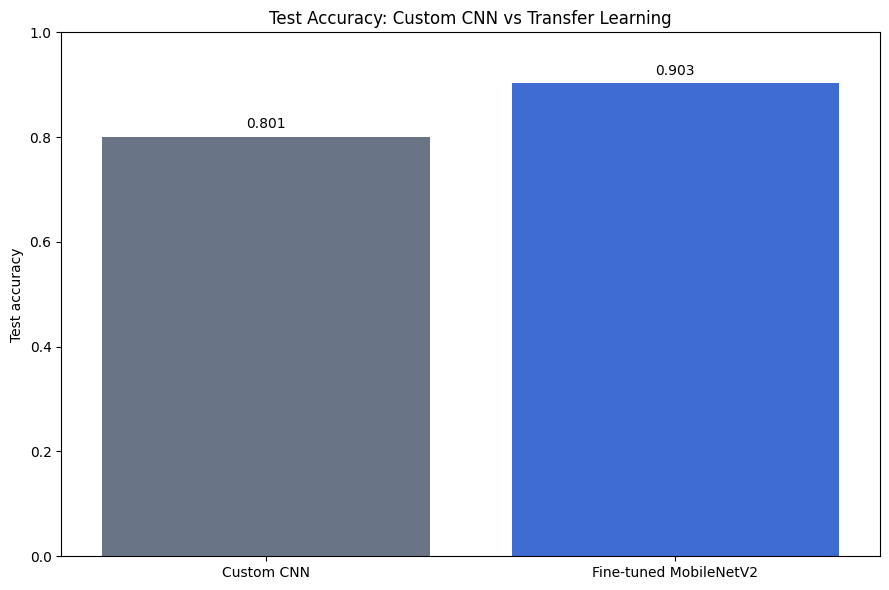

Artifacts created:
 - augmentation-examples.png
 - best-custom-cnn.keras
 - best-fine-tuned-model.keras
 - best-transfer-model.keras
 - class-distribution.png
 - classification-report.csv
 - confusion-matrices.png
 - final-fine-tuned-mobilenetv2.keras
 - final-model-comparison.png
 - gradcam-explanations.png
 - misclassified-images.png
 - model-comparison.csv
 - results-summary.json
 - sample-images.png

Downloadable archive: /kaggle/working/intel-scene-classification-artifacts.zip


In [18]:
import json
import shutil

# Save final in-memory model
transfer_model.save(
    OUTPUT_DIR / "final-fine-tuned-mobilenetv2.keras"
)

# Model-comparison visualization
plot_comparison = comparison_results.dropna(
    subset=["test_accuracy"]
).copy()

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=plot_comparison,
    x="model",
    y="test_accuracy",
    hue="model",
    palette=["#64748B", "#2563EB"],
    legend=False
)

plt.title("Test Accuracy: Custom CNN vs Transfer Learning")
plt.xlabel("")
plt.ylabel("Test accuracy")
plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=4
    )

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "final-model-comparison.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

# Machine-readable summary
results_summary = {
    "project": "Intel Scene Classification with Deep Learning",
    "random_seed": SEED,
    "image_size": list(IMG_SIZE),
    "training_images": 11228,
    "validation_images": 2806,
    "test_images": 3000,
    "classes": class_names,
    "custom_cnn": {
        "test_accuracy": float(custom_test_accuracy),
        "test_loss": float(custom_test_loss)
    },
    "fine_tuned_mobilenetv2": {
        "test_accuracy": float(fine_tuned_test_accuracy),
        "test_loss": float(fine_tuned_test_loss),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(macro_f1)
    },
    "principal_confusions": {
        "mountain_predicted_as_glacier": 72,
        "glacier_predicted_as_mountain": 52,
        "street_predicted_as_buildings": 50
    }
}

with open(
    OUTPUT_DIR / "results-summary.json",
    "w"
) as file:
    json.dump(
        results_summary,
        file,
        indent=2
    )

# Display everything captured for submission
artifact_files = sorted([
    path.name
    for path in OUTPUT_DIR.iterdir()
])

print("Artifacts created:")
for artifact in artifact_files:
    print(" -", artifact)

# Create one downloadable ZIP
archive_path = shutil.make_archive(
    "/kaggle/working/intel-scene-classification-artifacts",
    "zip",
    OUTPUT_DIR
)

print("\nDownloadable archive:", archive_path)

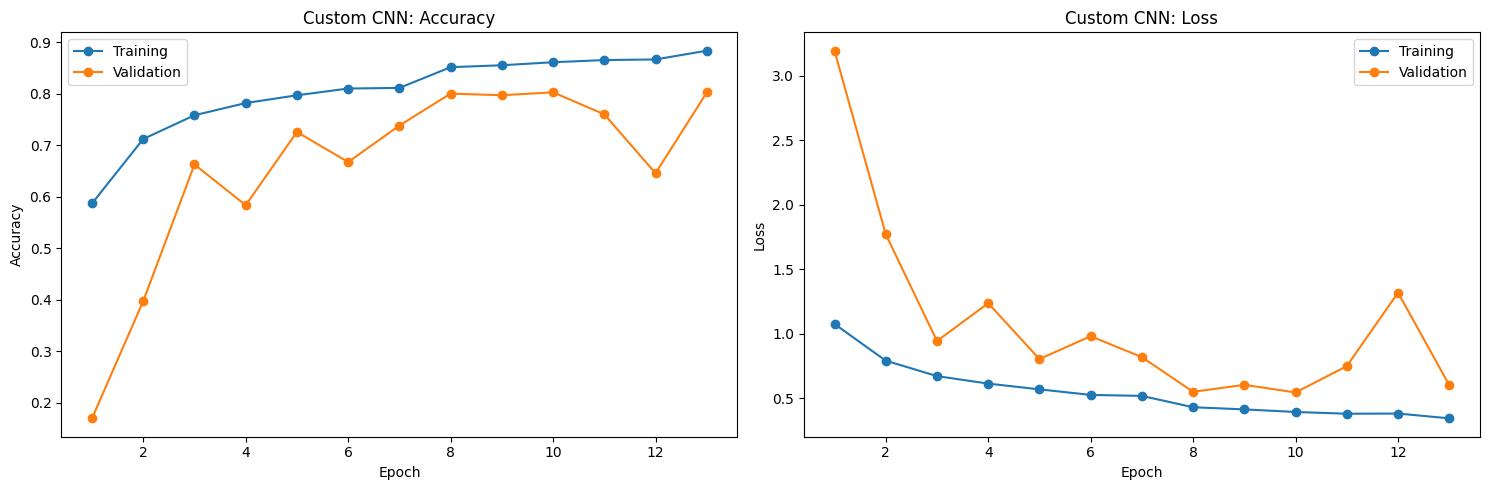

In [19]:
def plot_training_history(history, title, filename):
    history_data = pd.DataFrame(history.history)
    epochs = range(1, len(history_data) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(
        epochs,
        history_data["accuracy"],
        marker="o",
        label="Training"
    )
    axes[0].plot(
        epochs,
        history_data["val_accuracy"],
        marker="o",
        label="Validation"
    )
    axes[0].set_title(f"{title}: Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(
        epochs,
        history_data["loss"],
        marker="o",
        label="Training"
    )
    axes[1].plot(
        epochs,
        history_data["val_loss"],
        marker="o",
        label="Validation"
    )
    axes[1].set_title(f"{title}: Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / filename,
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()

plot_training_history(
    custom_history,
    "Custom CNN",
    "custom-cnn-learning-curves.png"
)